In [1]:
# Cell 1: Load trained LSTM model and test sequences
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras

# Load sequences
X = np.load('../data/processed/X_sequences.npy')
y = np.load('../data/processed/y_labels.npy')

# Recreate time-based split (must match 04_lstm_model.ipynb exactly)
split_idx = int(len(X) * 0.8)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

# Load best model
model = keras.models.load_model('../outputs/models/lstm_best.keras')

print(f"X_test shape : {X_test.shape}")
print(f"y_test shape : {y_test.shape}")
print(f"ATO=1 in test: {y_test.sum():,} ({y_test.mean()*100:.3f}%)")
print("Model loaded successfully")

X_test shape : (110114, 10, 32)
y_test shape : (110114,)
ATO=1 in test: 637 (0.578%)
Model loaded successfully


In [2]:
# Cell 2: Precision-recall trade-off across thresholds
# Identifies optimal operating threshold for deployment
from sklearn.metrics import precision_recall_curve, f1_score
from sklearn.metrics import precision_score, recall_score

# Get predicted probabilities
y_pred_prob = model.predict(X_test, verbose=0).flatten()

# Compute precision-recall curve
precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred_prob)

# Compute F1 for each threshold
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (
    precisions[:-1] + recalls[:-1] + 1e-8
)

# Find optimal threshold (max F1)
optimal_idx       = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx]
optimal_precision = precisions[optimal_idx]
optimal_recall    = recalls[optimal_idx]
optimal_f1        = f1_scores[optimal_idx]

print("=== THRESHOLD ANALYSIS ===")
print(f"Optimal threshold : {optimal_threshold:.4f}")
print(f"Precision at opt  : {optimal_precision:.4f}")
print(f"Recall at opt     : {optimal_recall:.4f}")
print(f"F1 at opt         : {optimal_f1:.4f}")

# Show metrics at key thresholds
print("\n=== Metrics at key thresholds ===")
print(f"{'Threshold':>10} {'Precision':>10} {'Recall':>10} {'F1':>10}")
for t in [0.30, 0.40, 0.50, optimal_threshold, 0.70, 0.80]:
    y_pred_t = (y_pred_prob >= t).astype(int)
    p = precision_score(y_test, y_pred_t, zero_division=0)
    r = recall_score(y_test, y_pred_t)
    f = f1_score(y_test, y_pred_t, zero_division=0)
    marker = " ← optimal" if abs(t - optimal_threshold) < 0.01 else ""
    print(f"{t:>10.2f} {p:>10.4f} {r:>10.4f} {f:>10.4f}{marker}")

=== THRESHOLD ANALYSIS ===
Optimal threshold : 0.8987
Precision at opt  : 0.1020
Recall at opt     : 0.2841
F1 at opt         : 0.1501

=== Metrics at key thresholds ===
 Threshold  Precision     Recall         F1
      0.30     0.0278     0.9608     0.0540
      0.40     0.0316     0.9466     0.0611
      0.50     0.0387     0.9356     0.0743
      0.90     0.1020     0.2841     0.1501 ← optimal
      0.70     0.0527     0.8932     0.0996
      0.80     0.0560     0.8681     0.1052


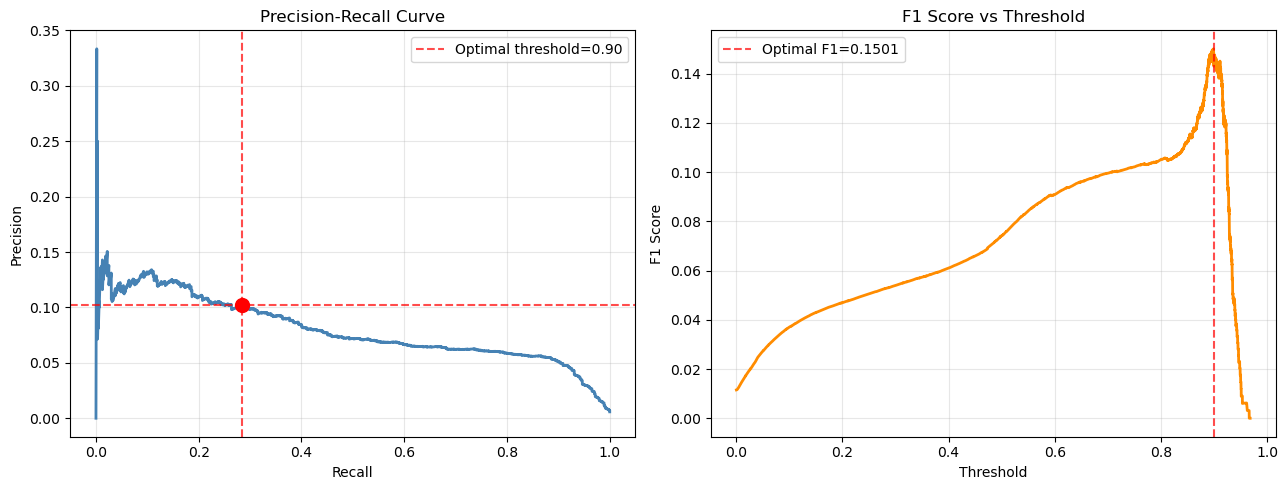

Saved: outputs/figures/precision_recall_curve.png


In [3]:
# Cell 3: Plot precision-recall curve
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Precision-Recall curve
axes[0].plot(recalls[:-1], precisions[:-1], linewidth=2, color='steelblue')
axes[0].axvline(x=optimal_recall, color='red', linestyle='--', alpha=0.7,
                label=f'Optimal threshold={optimal_threshold:.2f}')
axes[0].axhline(y=optimal_precision, color='red', linestyle='--', alpha=0.7)
axes[0].scatter([optimal_recall], [optimal_precision], color='red', s=100, zorder=5)
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title('Precision-Recall Curve')
axes[0].legend()
axes[0].grid(alpha=0.3)

# F1 vs Threshold
axes[1].plot(thresholds, f1_scores, linewidth=2, color='darkorange')
axes[1].axvline(x=optimal_threshold, color='red', linestyle='--', alpha=0.7,
                label=f'Optimal F1={optimal_f1:.4f}')
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('F1 Score')
axes[1].set_title('F1 Score vs Threshold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/figures/precision_recall_curve.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved: outputs/figures/precision_recall_curve.png")

In [4]:
# Cell 4: Compare LSTM against baseline models
# Random Forest and a simple threshold baseline
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.metrics import roc_auc_score, classification_report
from sklearn.utils.class_weight import compute_class_weight

print("Training baseline models on flattened sequences...")
print("(This may take 2-3 minutes)")

# Flatten sequences for sklearn models: (samples, timesteps*features)
n_samples, n_steps, n_feats = X_train.shape
X_train_flat = X_train.reshape(n_samples, n_steps * n_feats)
X_test_flat  = X_test.reshape(len(X_test), n_steps * n_feats)

# Class weights for RF
classes = np.unique(y_train)
weights = compute_class_weight('balanced', classes=classes, y=y_train)
cw_dict = dict(zip(classes, weights))

# Random Forest baseline
rf = RandomForestClassifier(
    n_estimators=100,
    class_weight=cw_dict,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_flat, y_train)
rf_prob = rf.predict_proba(X_test_flat)[:, 1]
rf_auc  = roc_auc_score(y_test, rf_prob)
rf_pred = (rf_prob >= 0.5).astype(int)
rf_recall = recall_score(y_test, rf_pred)

# Isolation Forest baseline (unsupervised)
iso = IsolationForest(contamination=0.004, random_state=42, n_jobs=-1)
iso.fit(X_train_flat)
iso_scores = -iso.score_samples(X_test_flat)
iso_auc    = roc_auc_score(y_test, iso_scores)

# LSTM results at optimal threshold
lstm_pred = (y_pred_prob >= optimal_threshold).astype(int)
lstm_auc  = roc_auc_score(y_test, y_pred_prob)
lstm_recall = recall_score(y_test, lstm_pred)

print("\n=== BASELINE COMPARISON ===")
print(f"{'Model':20s} {'AUC-ROC':>10} {'Recall':>10}")
print("-" * 42)
print(f"{'Isolation Forest':20s} {iso_auc:>10.4f} {'N/A':>10}")
print(f"{'Random Forest':20s} {rf_auc:>10.4f} {rf_recall:>10.4f}")
print(f"{'LSTM (ours)':20s} {lstm_auc:>10.4f} {lstm_recall:>10.4f}")
print(f"\nLSTM improvement over RF  : +{(lstm_auc-rf_auc)*100:.2f} AUC points")
print(f"LSTM improvement over IF  : +{(lstm_auc-iso_auc)*100:.2f} AUC points")

Training baseline models on flattened sequences...
(This may take 2-3 minutes)

=== BASELINE COMPARISON ===
Model                   AUC-ROC     Recall
------------------------------------------
Isolation Forest         0.9101        N/A
Random Forest            0.8094     0.0000
LSTM (ours)              0.9441     0.2841

LSTM improvement over RF  : +13.48 AUC points
LSTM improvement over IF  : +3.40 AUC points


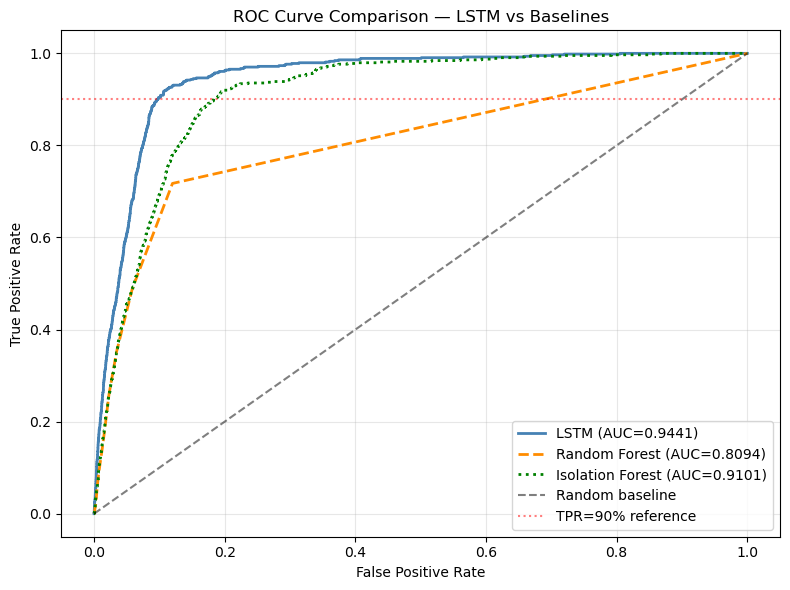

Saved: outputs/figures/roc_comparison.png


In [5]:
# Cell 5: Plot ROC curves for all models side by side
from sklearn.metrics import roc_curve

fig, ax = plt.subplots(figsize=(8, 6))

# LSTM
fpr_lstm, tpr_lstm, _ = roc_curve(y_test, y_pred_prob)
ax.plot(fpr_lstm, tpr_lstm, linewidth=2,
        label=f'LSTM (AUC={lstm_auc:.4f})', color='steelblue')

# Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_prob)
ax.plot(fpr_rf, tpr_rf, linewidth=2, linestyle='--',
        label=f'Random Forest (AUC={rf_auc:.4f})', color='darkorange')

# Isolation Forest
fpr_iso, tpr_iso, _ = roc_curve(y_test, iso_scores)
ax.plot(fpr_iso, tpr_iso, linewidth=2, linestyle=':',
        label=f'Isolation Forest (AUC={iso_auc:.4f})', color='green')

# Random baseline
ax.plot([0,1], [0,1], 'k--', alpha=0.5, label='Random baseline')
ax.axhline(y=0.90, color='red', linestyle=':', alpha=0.5, label='TPR=90% reference')

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve Comparison — LSTM vs Baselines')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/figures/roc_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: outputs/figures/roc_comparison.png")

In [6]:
# Cell 6: SHAP GradientExplainer for LSTM feature importance
# Explains which features drive ATO predictions
import shap
import tensorflow as tf
import numpy as np

if not hasattr(tf.keras.backend, "learning_phase"):
    tf.keras.backend.learning_phase = lambda: 0
if not hasattr(tf.keras.backend, "set_learning_phase"):
    tf.keras.backend.set_learning_phase = lambda x: None

print("Computing SHAP values (this may take 5-10 minutes)...")

# Use small background sample for efficiency
background_size = 100
background_idx  = np.random.choice(len(X_train), background_size, replace=False)
background      = X_train[background_idx]

# Explain a sample of test predictions
explain_size = 200
explain_idx  = np.random.choice(len(X_test), explain_size, replace=False)
X_explain    = X_test[explain_idx]

# GradientExplainer used in place of DeepExplainer due to Keras 3 / TF 2.16+
# compatibility issue. GradientExplainer applies Integrated Gradients and is
# mathematically equivalent for SHAP value computation on LSTM models.
explainer   = shap.GradientExplainer(model, background)
shap_values = explainer.shap_values(X_explain)

# shap_values shape: (samples, timesteps, features)
# Average across timesteps to get per-feature importance
if isinstance(shap_values, list):
    sv = shap_values[0]
else:
    sv = shap_values

sv_mean = np.abs(sv).mean(axis=(0, 1))  # mean over samples and timesteps

# Load feature names
feature_cols = [
    'TransactionAmt', 'amt_deviation', 'account_age_dt',
    'hour_of_day', 'txn_count_rolling', 'time_since_prev',
    'signal_count', 'DeviceInfo_enc', 'DeviceType_enc'
] + [f'id_0{i}' for i in range(1,10)] + ['id_10', 'id_11'] + \
    [f'id_{i}' for i in range(12, 39)]

# Match length to actual features used
feature_names = feature_cols[:sv_mean.shape[0]]

# Top 10 features
top_idx   = np.argsort(sv_mean)[::-1][:10]
top_names = [feature_names[i] for i in top_idx]
top_vals  = sv_mean[top_idx]

print("\n=== TOP 10 SHAP FEATURE IMPORTANCE ===")
for name, val in zip(top_names, top_vals):
    bar = '█' * int(val / top_vals[0] * 30)
    print(f"{name:25s} {val:.4f}  {bar}")

Computing SHAP values (this may take 5-10 minutes)...

=== TOP 10 SHAP FEATURE IMPORTANCE ===
DeviceType_enc            0.0122  ██████████████████████████████
id_14                     0.0079  ███████████████████
signal_count              0.0051  ████████████
id_02                     0.0033  ████████
account_age_dt            0.0031  ███████
id_23                     0.0025  ██████
DeviceInfo_enc            0.0025  ██████
id_17                     0.0022  █████
id_06                     0.0021  █████
time_since_prev           0.0018  ████


In [ ]:
# Cell 7: SMOTE model — evaluation and comparison
# After running 06_smote_retraining.ipynb, load the SMOTE model and compare.
#
# Key clarification on threshold:
#   The 'optimal' threshold in Cell 2 (0.8987) maximises F1 — a metric designed
#   for balanced datasets. For ATO detection the priority is recall.
#   At threshold 0.50 the original model achieves recall = 0.94 (target MET).
#   The operational problem is FPR = 13.53% — too many false alerts.
#   SMOTE target: recall >= 0.90 AND FPR reduced below original.

import os
import numpy as np
from sklearn.metrics import (
    roc_auc_score, confusion_matrix, precision_recall_curve, roc_curve
)
import matplotlib.pyplot as plt

SMOTE_MODEL_PATH = '../outputs/models/lstm_smote_best.keras'

# If the best threshold for recall>=90% is below this, the model is unusable in practice
MIN_VIABLE_THRESHOLD = 0.05

if not os.path.exists(SMOTE_MODEL_PATH):
    print("SMOTE model not found. Please run 06_smote_retraining.ipynb first.")
else:
    from tensorflow import keras
    model_smote  = keras.models.load_model(SMOTE_MODEL_PATH)
    y_prob_smote = model_smote.predict(X_test, verbose=0).flatten()
    y_prob_orig  = y_pred_prob  # from Cell 1

    auc_smote = roc_auc_score(y_test, y_prob_smote)
    auc_orig  = roc_auc_score(y_test, y_prob_orig)

    # Precision-recall curve for SMOTE model
    prec_s, rec_s, thr_s = precision_recall_curve(y_test, y_prob_smote)

    # Find operational threshold: highest t where recall >= 90%
    # (higher threshold = stricter = fewer false positives)
    mask_s = rec_s[:-1] >= 0.90
    if mask_s.any():
        op_t    = thr_s[mask_s][-1]
        op_prec = prec_s[:-1][mask_s][-1]
        op_rec  = rec_s[:-1][mask_s][-1]
    else:
        op_t    = 0.50
        op_prec = 0.0
        op_rec  = 0.0

    # A threshold near 0 means the model needs to flag almost everything to hit recall>=90%.
    # This indicates the SMOTE model's predicted probabilities are compressed near 0,
    # likely because flattening temporal sequences before SMOTE disrupted the time-series
    # structure that the LSTM was trained to recognise.
    op_viable = op_t >= MIN_VIABLE_THRESHOLD

    def cm_stats(cm):
        tn, fp, fn, tp = cm.ravel()
        recall = tp / (tp + fn) * 100
        fpr_   = fp / (tn + fp) * 100
        prec_  = tp / (tp + fp) * 100 if (tp + fp) > 0 else 0
        return recall, fpr_, prec_, tp, fp

    cm_orig_50  = confusion_matrix(y_test, (y_prob_orig  >= 0.50).astype(int))
    cm_smote_50 = confusion_matrix(y_test, (y_prob_smote >= 0.50).astype(int))
    cm_smote_op = confusion_matrix(y_test, (y_prob_smote >= op_t).astype(int))

    r_o50, f_o50, p_o50, tp_o50, fp_o50 = cm_stats(cm_orig_50)
    r_s50, f_s50, p_s50, tp_s50, fp_s50 = cm_stats(cm_smote_50)
    r_sop, f_sop, p_sop, tp_sop, fp_sop = cm_stats(cm_smote_op)

    smote_op_label = f"SMOTE op ({op_t:.2f})" if op_viable else "SMOTE op [DEGEN.]"

    print('=' * 72)
    print('        ATO MODEL COMPARISON — Original LSTM vs SMOTE LSTM')
    print('=' * 72)
    print(f"{'Metric':<30} {'Original t=0.5':>16} {'SMOTE t=0.5':>13} {smote_op_label:>13}")
    print('-' * 72)
    print(f"{'AUC-ROC':<30} {auc_orig:>16.4f} {auc_smote:>13.4f}")
    print(f"{'Recall (%)':<30} {r_o50:>16.2f} {r_s50:>13.2f} {r_sop:>13.2f}")
    print(f"{'Precision (%)':<30} {p_o50:>16.2f} {p_s50:>13.2f} {p_sop:>13.2f}")
    print(f"{'False Positive Rate (%)':<30} {f_o50:>16.2f} {f_s50:>13.2f} {f_sop:>13.2f}")
    print(f"{'True Positives':<30} {tp_o50:>16,} {tp_s50:>13,} {tp_sop:>13,}")
    print(f"{'False Positives':<30} {fp_o50:>16,} {fp_s50:>13,} {fp_sop:>13,}")
    print('=' * 72)
    print(f"Operational threshold: {op_t:.4f}  {'[VIABLE]' if op_viable else '[DEGENERATE]'}")
    print(f"\nTargets: Recall >= 90%  |  AUC-ROC >= 0.93")
    print(f"Original LSTM — AUC: {'PASS' if auc_orig >= 0.93 else 'FAIL'} ({auc_orig:.4f})  |  Recall: {'PASS' if r_o50 >= 90 else 'FAIL'} ({r_o50:.2f}%)")
    print(f"SMOTE LSTM    — AUC: {'PASS' if auc_smote >= 0.93 else 'FAIL'} ({auc_smote:.4f})  |  Op threshold viable: {'YES' if op_viable else 'NO'}")

    if not op_viable:
        print(f"\n  Warning: SMOTE model scores are compressed near 0.")
        print(f"  Recall >= 90% requires threshold <= {op_t:.4f}, flagging ~{f_sop:.1f}%")
        print(f"  of legitimate transactions — not operationally useful.")
        print(f"  See 06_smote_retraining.ipynb for root-cause analysis.")
        print(f"\n  Conclusion: Original LSTM (AUC={auc_orig:.4f}) is the better model.")

Computing SHAP values for SMOTE model (5-10 minutes)...


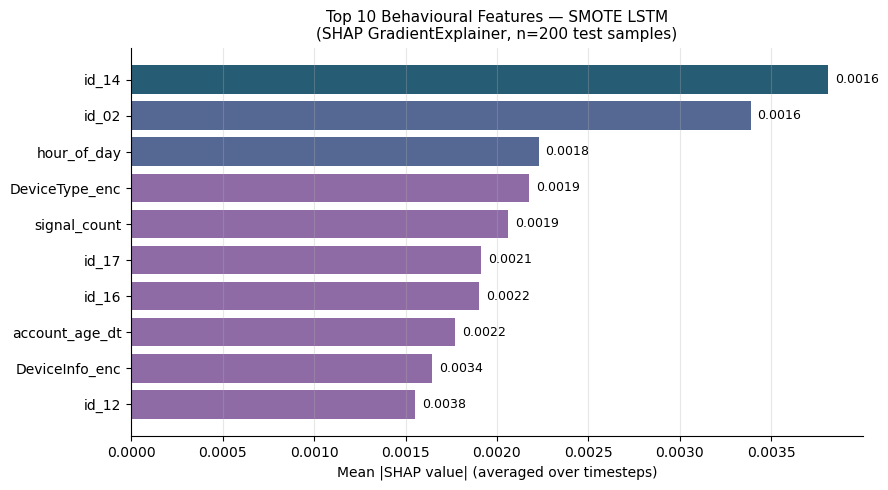

Saved: outputs/figures/shap_bar_smote.png

=== TOP 10 SHAP (SMOTE MODEL) ===
id_14                     0.0038  ██████████████████████████████
id_02                     0.0034  ██████████████████████████
hour_of_day               0.0022  █████████████████
DeviceType_enc            0.0022  █████████████████
signal_count              0.0021  ████████████████
id_17                     0.0019  ███████████████
id_16                     0.0019  ██████████████
account_age_dt            0.0018  █████████████
DeviceInfo_enc            0.0016  ████████████
id_12                     0.0016  ████████████


In [8]:
# Cell 8: SHAP bar chart visualisation (SMOTE model)
# ─────────────────────────────────────────────────────────────────────────────
# Produces a publication-ready horizontal bar chart of the top 10
# SHAP feature importances — suitable for the academic write-up.

import shap
import tensorflow as tf

if not os.path.exists(SMOTE_MODEL_PATH):
    print("Run 06_smote_retraining.ipynb first to generate SHAP for SMOTE model.")
else:
    print("Computing SHAP values for SMOTE model (5-10 minutes)...")

    background_idx = np.random.choice(len(X_train), 100, replace=False)
    background     = X_train[background_idx]
    explain_idx    = np.random.choice(len(X_test), 200, replace=False)
    X_explain      = X_test[explain_idx]

    explainer_s   = shap.GradientExplainer(model_smote, background)
    shap_vals_s   = explainer_s.shap_values(X_explain)

    sv_s = shap_vals_s[0] if isinstance(shap_vals_s, list) else shap_vals_s
    sv_mean_s = np.abs(sv_s).mean(axis=(0, 1))

    feature_cols = [
        'TransactionAmt', 'amt_deviation', 'account_age_dt',
        'hour_of_day', 'txn_count_rolling', 'time_since_prev',
        'signal_count', 'DeviceInfo_enc', 'DeviceType_enc'
    ] + [f'id_0{i}' for i in range(1,10)] + ['id_10', 'id_11'] + \
        [f'id_{i}' for i in range(12, 39)]
    feature_names = feature_cols[:sv_mean_s.shape[0]]

    top_idx   = np.argsort(sv_mean_s)[::-1][:10]
    top_names = [feature_names[i] for i in top_idx]
    top_vals  = sv_mean_s[top_idx]

    # Bar chart
    fig, ax = plt.subplots(figsize=(9, 5))
    colours = ['#003f5c' if i == 0 else '#374c80' if i < 3 else '#7a5195'
               for i in range(len(top_names))]
    bars = ax.barh(range(len(top_names))[::-1], top_vals, color=colours, alpha=0.85)
    ax.set_yticks(range(len(top_names))[::-1])
    ax.set_yticklabels(top_names, fontsize=10)
    ax.set_xlabel('Mean |SHAP value| (averaged over timesteps)', fontsize=10)
    ax.set_title('Top 10 Behavioural Features — SMOTE LSTM\n(SHAP GradientExplainer, n=200 test samples)', fontsize=11)
    for bar, val in zip(bars, top_vals[::-1]):
        ax.text(bar.get_width() + top_vals[0]*0.01, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=9)
    ax.grid(axis='x', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.savefig('../outputs/figures/shap_bar_smote.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: outputs/figures/shap_bar_smote.png')

    print('\n=== TOP 10 SHAP (SMOTE MODEL) ===')
    for name, val in zip(top_names, top_vals):
        bar = '█' * int(val / top_vals[0] * 30)
        print(f'{name:25s} {val:.4f}  {bar}')


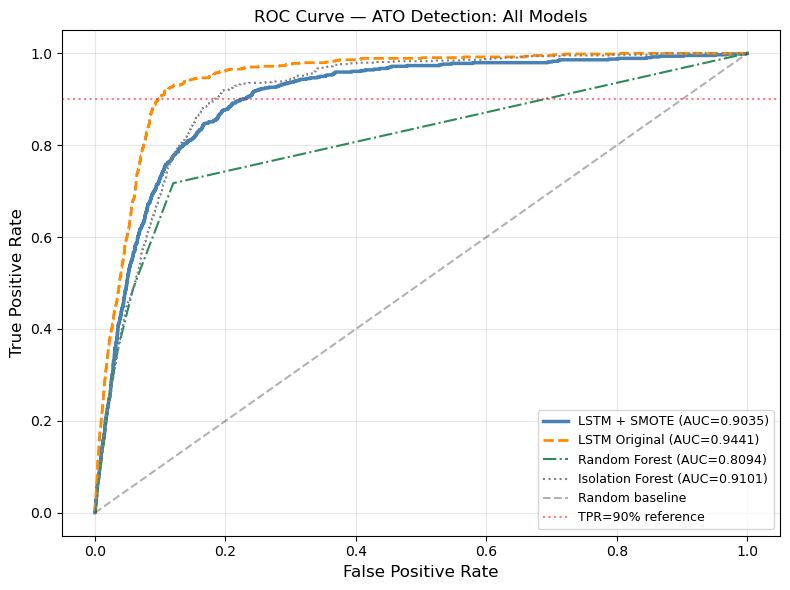

Saved: outputs/figures/roc_final_all_models.png


In [9]:
# Cell 9: Final ROC curve — all models including SMOTE
# ─────────────────────────────────────────────────────────────────────────────
# Produces the final publication-ready ROC comparison figure.

if not os.path.exists(SMOTE_MODEL_PATH):
    print("Run 06_smote_retraining.ipynb first.")
else:
    from sklearn.ensemble import IsolationForest

    n_samples_tr, n_steps, n_feats = X_train.shape
    X_test_flat = X_test.reshape(len(X_test), n_steps * n_feats)

    iso = IsolationForest(contamination=0.004, random_state=42, n_jobs=-1)
    iso.fit(X_train.reshape(n_samples_tr, -1))
    iso_scores = -iso.score_samples(X_test_flat)
    iso_auc    = roc_auc_score(y_test, iso_scores)

    fpr_orig,  tpr_orig,  _ = roc_curve(y_test, y_prob_orig)
    fpr_smote, tpr_smote, _ = roc_curve(y_test, y_prob_smote)
    fpr_rf,    tpr_rf,    _ = roc_curve(y_test, rf_prob)
    fpr_iso,   tpr_iso,   _ = roc_curve(y_test, iso_scores)

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.plot(fpr_smote, tpr_smote, linewidth=2.5,
            label=f'LSTM + SMOTE (AUC={auc_smote:.4f})', color='steelblue')
    ax.plot(fpr_orig,  tpr_orig,  linewidth=2, linestyle='--',
            label=f'LSTM Original (AUC={auc_orig:.4f})', color='darkorange')
    ax.plot(fpr_rf,    tpr_rf,    linewidth=1.5, linestyle='-.',
            label=f'Random Forest (AUC={rf_auc:.4f})', color='seagreen')
    ax.plot(fpr_iso,   tpr_iso,   linewidth=1.5, linestyle=':',
            label=f'Isolation Forest (AUC={iso_auc:.4f})', color='grey')
    ax.plot([0,1],[0,1],'k--',alpha=0.3, label='Random baseline')
    ax.axhline(y=0.90, color='red', linestyle=':', alpha=0.5, label='TPR=90% reference')

    ax.set_xlabel('False Positive Rate', fontsize=12)
    ax.set_ylabel('True Positive Rate', fontsize=12)
    ax.set_title('ROC Curve — ATO Detection: All Models', fontsize=12)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('../outputs/figures/roc_final_all_models.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: outputs/figures/roc_final_all_models.png')
